In [3]:
import os
import time
import pandas as pd
import threading
from concurrent.futures import ThreadPoolExecutor, as_completed
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import pandas as pd
import glob

In [2]:
MAX_THREADS = 2
YEARS = list(range(2021, 2041))
CHUNK_SIZE = 5

driver_lock = threading.Lock()

country_codes = [
    "australia","bangladesh","brazil","bulgaria","canada","china","czech",
    "denmark","finland","france","germany","greece","hong-kong","hungary","india",
    "indonesia","israel","italy","japan","kenya","north-korea","south-korea",
    "malaysia","mongolia","morocco","netherlands","norway","pakistan","philippines",
    "poland","portugal","romania","russia","slovenia","south-africa","spain",
    "sri-lanka","sweden","taiwan","thailand","turkey","vietnam","ukraine","uk",
    "new-zealand","belgium","luxembourg","chile","paraguay","slovakia","ireland",
    "iceland","us"
]

def setup_driver():
    options = Options()
    options.add_argument("--headless=new")
    options.add_argument("--disable-gpu")
    options.add_argument("--no-sandbox")
    options.add_argument("--disable-dev-shm-usage")
    options.add_argument("--disable-extensions")
    options.page_load_strategy = 'eager'

    prefs = {"profile.managed_default_content_settings.images": 2}
    options.add_experimental_option("prefs", prefs)

    return webdriver.Chrome(options=options)

def get_driver_with_retry(country, year, retries=3):
    for attempt in range(retries):
        try:
            with driver_lock:
                time.sleep(0.5)
                return setup_driver()
        except Exception as e:
            print(f"[RETRY] Driver failed for {country} {year}, attempt {attempt+1}")
            time.sleep(1)
    print(f"[FAIL] Driver could not start for {country} {year}")
    return None

def fetch_public_holidays(country, year):
    url = f"https://www.timeanddate.com/holidays/{country}/{year}?hol=1"
    holidays = []

    driver = get_driver_with_retry(country, year)
    if driver is None:
        return holidays

    try:
        print(f"[START] {country.upper()} {year}")
        driver.get(url)
        time.sleep(1)

        try:
            WebDriverWait(driver, 5).until(
                EC.presence_of_element_located((By.ID, "holidays-table"))
            )
            rows = driver.find_elements(By.CSS_SELECTOR, "#holidays-table tbody tr")
        except:
            print(f"[WARN] Table not found for {country} {year}")
            rows = []

        for row in rows:
            try:
                th = row.find_element(By.TAG_NAME, "th")
                cols = row.find_elements(By.TAG_NAME, "td")

                if len(cols) < 3:
                    continue

                type_val = cols[2].text.strip()
                if "Holiday" not in type_val:
                    continue

                raw_date = th.text.strip()
                day = cols[0].text.strip()
                name = cols[1].text.strip()

                try:
                    date_obj = pd.to_datetime(f"{raw_date} {year}", format="%d %b %Y")
                    formatted_date = date_obj.strftime("%d-%b-%y")
                except:
                    continue

                holidays.append({
                    "Date": formatted_date,
                    "Day": day,
                    "Name": name,
                    "Type": type_val,
                    "Country": country
                })

            except:
                continue

        print(f"[DONE] {country.upper()} {year} -> {len(holidays)} rows")

    except Exception as e:
        print(f"[ERROR] {country} {year}: {e}")

    finally:
        try:
            driver.quit()
        except:
            pass

    return holidays

def scrape_all():
    for year in YEARS:
        print(f"\n========== START YEAR {year} ==========")

        for i in range(0, len(country_codes), CHUNK_SIZE):
            filename = f"holidays_{year}_part{i}.csv"

            if os.path.exists(filename):
                print(f"[SKIP] {filename} already exists")
                continue

            country_chunk = country_codes[i:i + CHUNK_SIZE]
            print(f"\n[CHUNK] Year {year} -> {country_chunk}")

            results = []

            with ThreadPoolExecutor(MAX_THREADS) as executor:
                futures = [
                    executor.submit(fetch_public_holidays, country, year)
                    for country in country_chunk
                ]

                for future in as_completed(futures):
                    try:
                        data = future.result()
                        if data:
                            results.extend(data)
                    except Exception as e:
                        print(f"[THREAD ERROR] {e}")

            df_chunk = pd.DataFrame(results)
            df_chunk.to_csv(filename, index=False, encoding="utf-8-sig")

            print(f"[SAVED] {filename} -> {len(df_chunk)} rows")

        print(f"========== COMPLETED YEAR {year} ==========")

if __name__ == "__main__":
    scrape_all()


========== START YEAR 2021 ==========

[CHUNK] Year 2021 -> ['australia', 'bangladesh', 'brazil', 'bulgaria', 'canada']
[START] AUSTRALIA 2021
[START] BANGLADESH 2021
[DONE] AUSTRALIA 2021 -> 7 rows
[DONE] BANGLADESH 2021 -> 30 rows
[START] BRAZIL 2021
[START] BULGARIA 2021
[DONE] BRAZIL 2021 -> 16 rows
[DONE] BULGARIA 2021 -> 17 rows
[START] CANADA 2021
[DONE] CANADA 2021 -> 11 rows
[SAVED] holidays_2021_part0.csv -> 81 rows

[CHUNK] Year 2021 -> ['china', 'czech', 'denmark', 'finland', 'france']
[START] CHINA 2021
[START] CZECH 2021
[DONE] CZECH 2021 -> 14 rows
[DONE] CHINA 2021 -> 31 rows
[START] DENMARK 2021
[START] FINLAND 2021
[DONE] DENMARK 2021 -> 14 rows
[DONE] FINLAND 2021 -> 11 rows
[START] FRANCE 2021
[DONE] FRANCE 2021 -> 11 rows
[SAVED] holidays_2021_part5.csv -> 81 rows

[CHUNK] Year 2021 -> ['germany', 'greece', 'hong-kong', 'hungary', 'india']
[START] GERMANY 2021
[START] GREECE 2021
[DONE] GREECE 2021 -> 2 rows
[DONE] GERMANY 2021 -> 9 rows
[START] HONG-KONG 2021
[DO

In [4]:
print("Loading all CSV files...")

# Step 1: Load all partial files
files = glob.glob("holidays_*.csv")

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

print(f"Total rows loaded: {len(df)}")

# Step 2: Extract Year from Date
df["Year"] = pd.to_datetime(df["Date"], format="%d-%b-%y").dt.year

# Step 3: Group → Country + Year
grouped = df.groupby(["Country", "Year"]).size().reset_index(name="Holiday_Count")

print("Grouping completed")

# Step 4: Pivot (FINAL FORMAT)
pivot = grouped.pivot(index="Country", columns="Year", values="Holiday_Count")

# Step 5: Sort (optional but clean)
pivot = pivot.sort_index()

# Step 6: Fill missing values (important)
pivot = pivot.fillna(0).astype(int)

# Step 7: Save
pivot.to_csv("country_year_holiday_matrix.csv")

print("Final matrix saved: country_year_holiday_matrix.csv")

# Step 8: Preview
print(pivot.head())

Loading all CSV files...
Total rows loaded: 12753
Grouping completed
Final matrix saved: country_year_holiday_matrix.csv
Year        2021  2022  2023  2024  2025  2026  2027  2028  2029  2030  2031  \
Country                                                                        
australia      7     8     7     7     7     7     7     7     7     7     7   
bangladesh    30    22    24    24    27    31     0     0     0     0     0   
belgium       10    10    10    10    10    10    10    10    10    10    10   
brazil        16    16    16    17    17    17    17    17    17    17    17   
bulgaria      17    18    17    16    17    18    17    17    17    16    16   

Year        2032  2033  2034  2035  2036  2037  2038  2039  2040  
Country                                                           
australia      7     7     7     7     7     7     7     7     7  
bangladesh     0     0     0     0     0     0     0     0     0  
belgium       10    10    10    10    10    10    

In [5]:
print("Loading all holiday files...")

# Step 1: Get all CSV files
files = glob.glob("holidays_*.csv")

print(f"Total files found: {len(files)}")

# Step 2: Read and merge
df_list = []

for file in files:
    try:
        df = pd.read_csv(file)
        df_list.append(df)
        print(f"[LOADED] {file} -> {len(df)} rows")
    except Exception as e:
        print(f"[ERROR] {file}: {e}")

# Step 3: Combine
final_df = pd.concat(df_list, ignore_index=True)

print(f"Total merged rows: {len(final_df)}")

# Step 4: Save final file
final_df.to_csv("holidays_all.csv", index=False, encoding="utf-8-sig")

print("Final file saved: holidays_all.csv")

Loading all holiday files...
Total files found: 220
[LOADED] holidays_2021_part0.csv -> 81 rows
[LOADED] holidays_2021_part10.csv -> 59 rows
[LOADED] holidays_2021_part15.csv -> 62 rows
[LOADED] holidays_2021_part20.csv -> 67 rows
[LOADED] holidays_2021_part25.csv -> 62 rows
[LOADED] holidays_2021_part30.csv -> 80 rows
[LOADED] holidays_2021_part35.csv -> 96 rows
[LOADED] holidays_2021_part40.csv -> 69 rows
[LOADED] holidays_2021_part45.csv -> 72 rows
[LOADED] holidays_2021_part5.csv -> 81 rows
[LOADED] holidays_2021_part50.csv -> 39 rows
[LOADED] holidays_2022_part0.csv -> 77 rows
[LOADED] holidays_2022_part10.csv -> 60 rows
[LOADED] holidays_2022_part15.csv -> 59 rows
[LOADED] holidays_2022_part20.csv -> 73 rows
[LOADED] holidays_2022_part25.csv -> 64 rows
[LOADED] holidays_2022_part30.csv -> 78 rows
[LOADED] holidays_2022_part35.csv -> 103 rows
[LOADED] holidays_2022_part40.csv -> 63 rows
[LOADED] holidays_2022_part45.csv -> 69 rows
[LOADED] holidays_2022_part5.csv -> 78 rows
[LOADE

In [6]:
print(final_df["Country"].nunique())
print(final_df.shape)

52
(12753, 5)


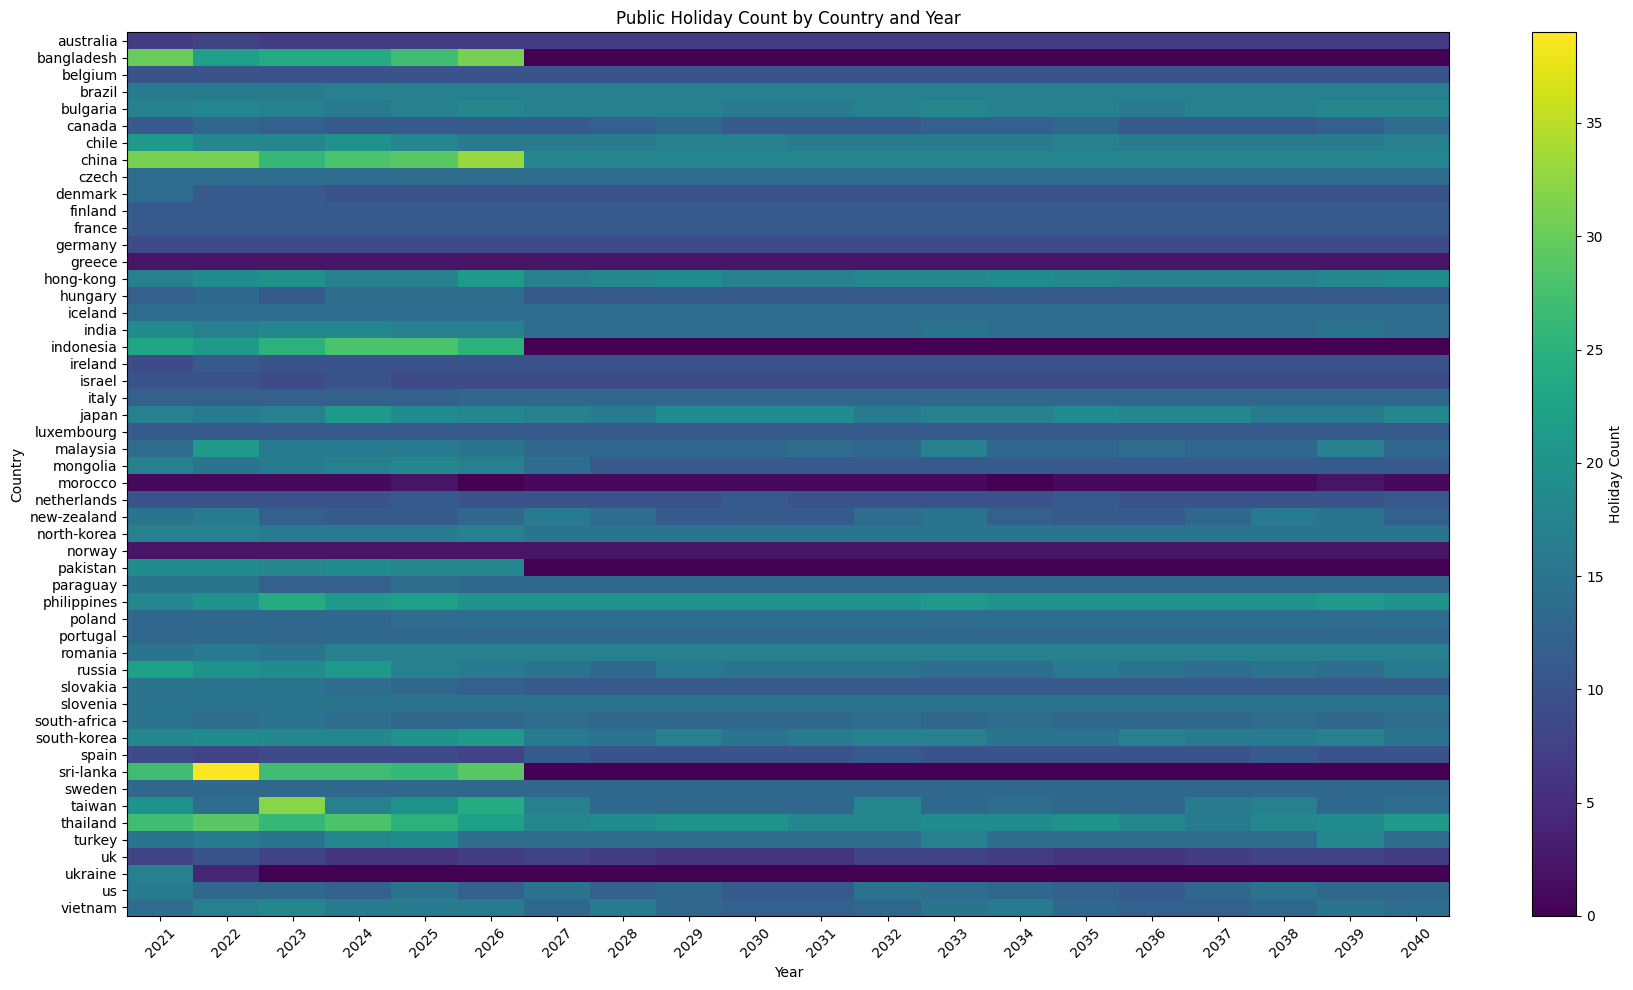

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load final merged dataset
df = pd.read_csv("holidays_all.csv")

# Convert Date to Year
df["Year"] = pd.to_datetime(df["Date"], format="%d-%b-%y").dt.year

# Aggregate
grouped = df.groupby(["Country", "Year"]).size().reset_index(name="Holiday_Count")

# Pivot
pivot = grouped.pivot(index="Country", columns="Year", values="Holiday_Count")

# Fill missing
pivot = pivot.fillna(0)

# Plot
plt.figure(figsize=(18, 10))
plt.imshow(pivot, aspect='auto')

plt.colorbar(label="Holiday Count")
plt.xticks(ticks=range(len(pivot.columns)), labels=pivot.columns, rotation=45)
plt.yticks(ticks=range(len(pivot.index)), labels=pivot.index)

plt.title("Public Holiday Count by Country and Year")
plt.xlabel("Year")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

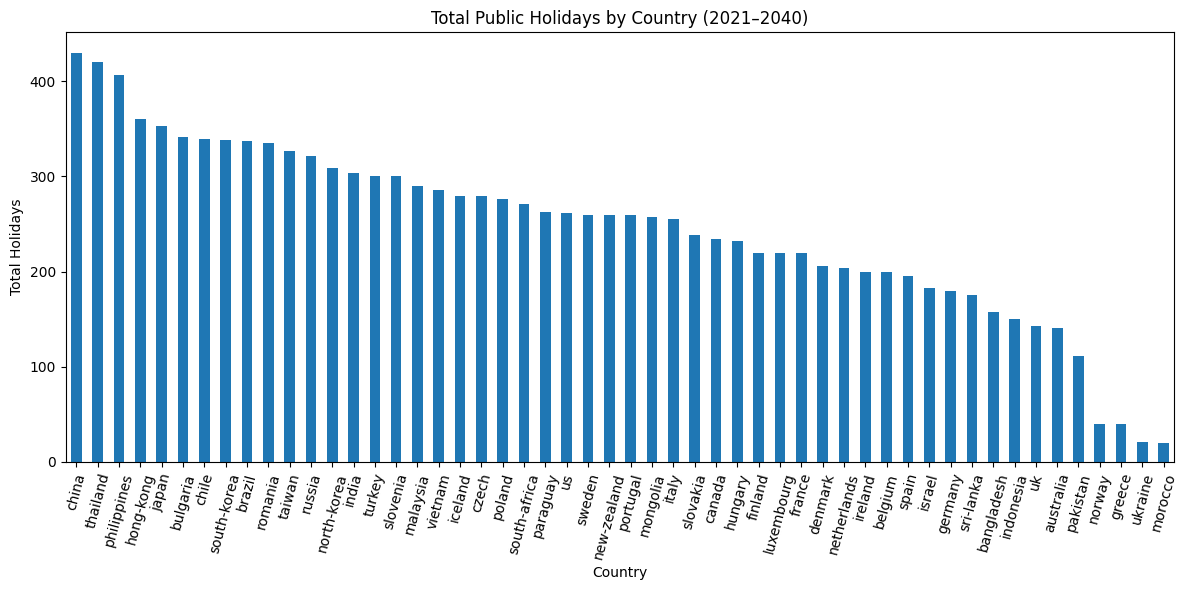

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("holidays_all.csv")

# Extract year
df["Year"] = pd.to_datetime(df["Date"], format="%d-%b-%y").dt.year

# Aggregate total holidays per country
country_counts = df.groupby("Country").size().sort_values(ascending=False)

# Plot
plt.figure(figsize=(12,6))
country_counts.plot(kind="bar")

plt.title("Total Public Holidays by Country (2021–2040)")
plt.xlabel("Country")
plt.ylabel("Total Holidays")

plt.xticks(rotation=75)
plt.tight_layout()
plt.show()